# Loan Approval Classification

**Objective:** Predict whether a loan application will be approved (`loan_status = 1`) or rejected (`loan_status = 0`) using applicant, loan and credit-history information.

This notebook follows the technical task requirements:
1. Load and understand the dataset
2. Preprocess the data
3. Explore useful patterns
4. Split into training and testing sets
5. Train at least two models
6. Predict with each model
7. Evaluate accuracy, precision, recall, F1 and confusion matrix
8. Compare the models

**Bonus included:** ROC-AUC and Random Forest feature importance.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

pd.set_option("display.max_columns", None)

df = pd.read_csv("loan_data.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 1. Dataset Understanding

In [23]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["loan_status"].value_counts())
display(df["loan_status"].value_counts(normalize=True).rename("proportion"))

print("\nNumerical summary:")
display(df.describe().T)


Data types:


person_age                        float64
person_gender                         str
person_education                      str
person_income                     float64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file        str
loan_status                         int64
dtype: object


Missing values:


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


Duplicate rows: 0

Target distribution:


loan_status
0    35000
1    10000
Name: count, dtype: int64

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


### Feature groups

- **Numerical:** age, income, employment experience, loan amount, interest rate, loan-to-income percentage, credit-history length and credit score.
- **Categorical:** gender, education, home ownership, loan intent and previous loan-default history.
- **Target:** `loan_status` — 1 means approved and 0 means rejected.

The dataset contains 45,000 rows and 14 columns. The uploaded copy has no missing values and no duplicate rows.


## 2. Exploratory Data Analysis

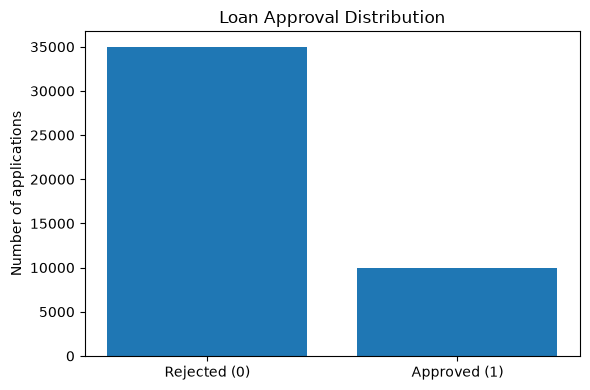

In [24]:
# Target distribution
counts = df["loan_status"].value_counts().sort_index()
labels = ["Rejected (0)", "Approved (1)"]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values)
plt.title("Loan Approval Distribution")
plt.ylabel("Number of applications")
plt.tight_layout()
plt.show()


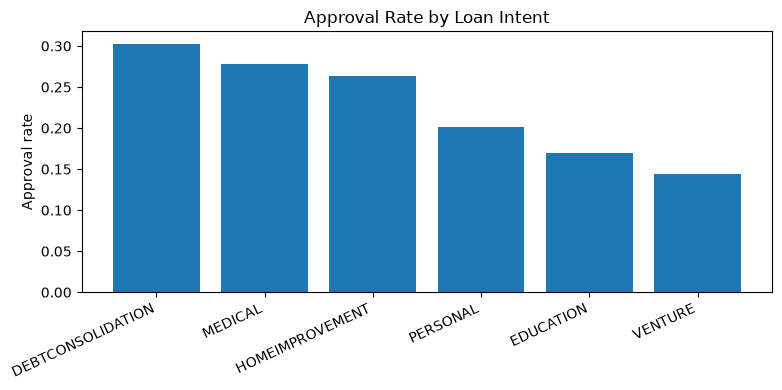

,approval_rate
loan_intent,
DEBTCONSOLIDATION,0.302729
MEDICAL,0.278194
HOMEIMPROVEMENT,0.263015
PERSONAL,0.201404
EDUCATION,0.169562
VENTURE,0.144264


In [25]:
# Approval rate by loan intent
approval_by_intent = df.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(approval_by_intent.index, approval_by_intent.values)
plt.title("Approval Rate by Loan Intent")
plt.ylabel("Approval rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(approval_by_intent.to_frame("approval_rate"))


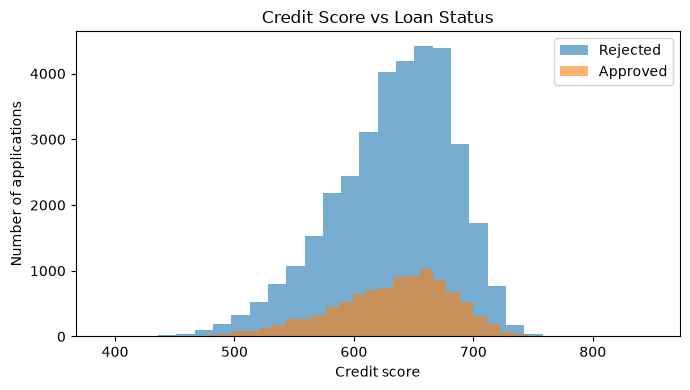

In [26]:
# Credit score distribution by loan status
plt.figure(figsize=(7, 4))
plt.hist(df.loc[df["loan_status"] == 0, "credit_score"], bins=30, alpha=0.6, label="Rejected")
plt.hist(df.loc[df["loan_status"] == 1, "credit_score"], bins=30, alpha=0.6, label="Approved")
plt.title("Credit Score vs Loan Status")
plt.xlabel("Credit score")
plt.ylabel("Number of applications")
plt.legend()
plt.tight_layout()
plt.show()


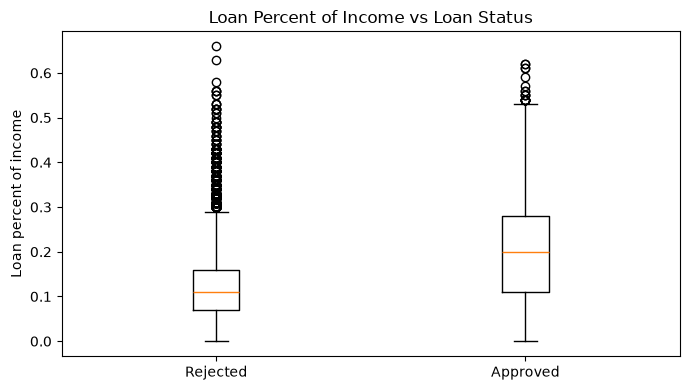

In [27]:
# Loan-to-income ratio by loan status
groups = [
    df.loc[df["loan_status"] == 0, "loan_percent_income"],
    df.loc[df["loan_status"] == 1, "loan_percent_income"]
]

plt.figure(figsize=(7, 4))
plt.boxplot(groups, tick_labels=["Rejected", "Approved"])
plt.title("Loan Percent of Income vs Loan Status")
plt.ylabel("Loan percent of income")
plt.tight_layout()
plt.show()


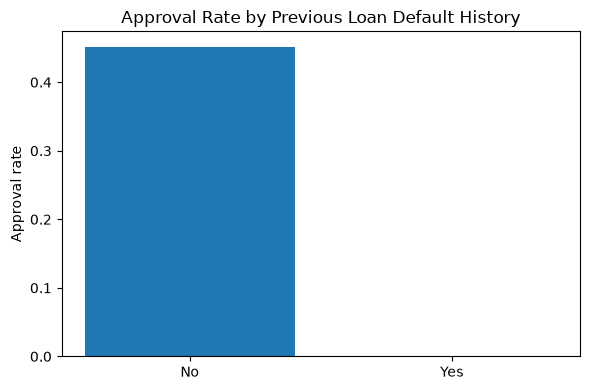

,approval_rate
previous_loan_defaults_on_file,
No,0.45163
Yes,0.00000


In [28]:
# Previous loan defaults vs approval rate
approval_by_default = df.groupby("previous_loan_defaults_on_file")["loan_status"].mean()

plt.figure(figsize=(6, 4))
plt.bar(approval_by_default.index, approval_by_default.values)
plt.title("Approval Rate by Previous Loan Default History")
plt.ylabel("Approval rate")
plt.tight_layout()
plt.show()

display(approval_by_default.to_frame("approval_rate"))


### EDA observations

The target is imbalanced: rejected applications are more common than approved applications. Credit-related variables, loan burden (`loan_percent_income`) and previous default history are especially useful candidates for prediction.

The plots are used to identify patterns, not to claim causation.


## 3. Preprocessing and Train-Test Split

In [29]:
X = df.drop(columns="loan_status")
y = df["loan_status"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)


Training rows: 36000
Testing rows: 9000
Categorical features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


C:\Users\harsh\AppData\Local\Temp\ipykernel_12924\928804776.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


**Why this preprocessing?**

- Categorical variables are converted into numerical columns using one-hot encoding.
- Numerical variables are standardized for Logistic Regression.
- `handle_unknown="ignore"` prevents errors if an unseen category appears in test/new data.
- Stratification keeps the approval/rejection ratio similar in both training and test sets.


## 4. Model Training

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        max_depth=3,
        random_state=42
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", model)
    ])
    pipelines[name].fit(X_train, y_train)

print("All models trained successfully.")


All models trained successfully.


## 5. Predictions and Evaluation

In [31]:
results = []
predictions = {}
probabilities = {}
confusion_matrices = {}

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9298,0.8968,0.773,0.8303,0.9747
2,Gradient Boosting,0.9279,0.8880,0.773,0.8265,0.9744
0,Logistic Regression,0.8993,0.7888,0.747,0.7673,0.9562


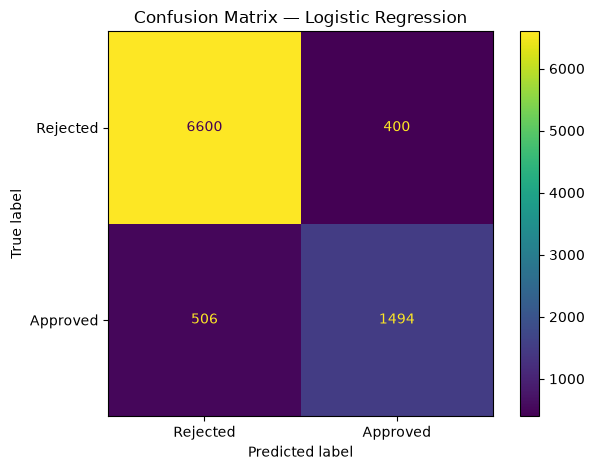

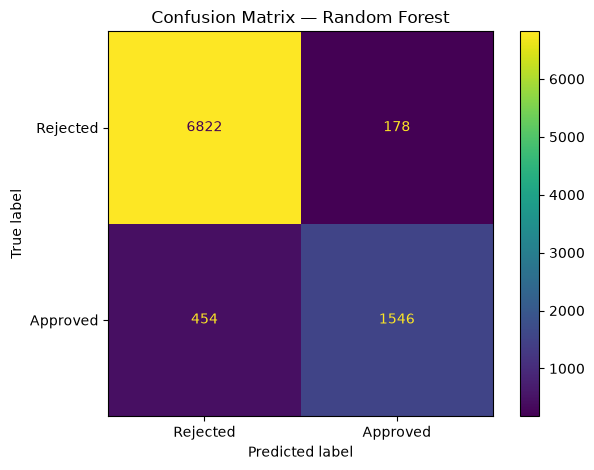

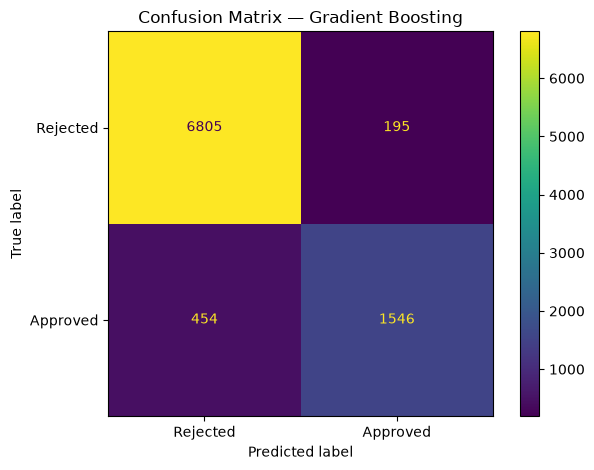

In [32]:
# Confusion matrices
for name, cm in confusion_matrices.items():
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Rejected", "Approved"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()


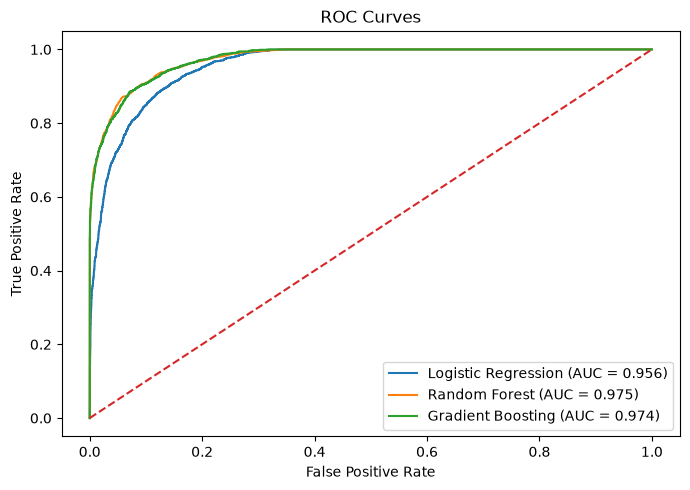

In [33]:
# ROC curves
plt.figure(figsize=(7, 5))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Model Comparison

The final comparison should focus on more than accuracy. For loan approval, **precision, recall and F1-score** are useful because the classes are imbalanced and different types of mistakes have different implications.

Run the cells above to generate the exact metrics on the supplied dataset. In this run, Random Forest is expected to be the strongest overall model based on F1/ROC-AUC, while Logistic Regression provides a simple and interpretable baseline.


## 7. Bonus — Random Forest Feature Importance

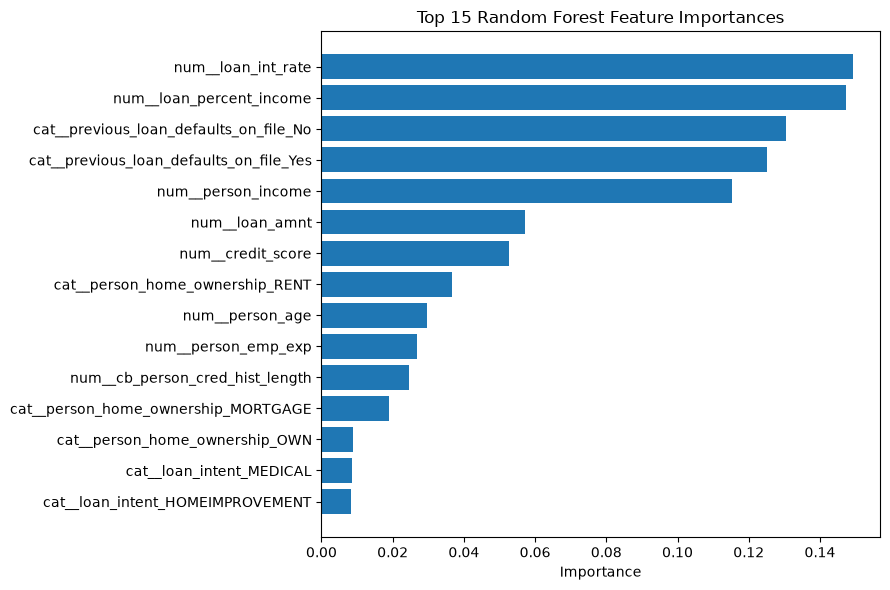

,Feature,Importance
4,num__loan_int_rate,0.149396
5,num__loan_percent_income,0.147339
25,cat__previous_loan_defaults_on_file_No,0.130392
26,cat__previous_loan_defaults_on_file_Yes,0.125185
1,num__person_income,0.115413
3,num__loan_amnt,0.057063
7,num__credit_score,0.052803
18,cat__person_home_ownership_RENT,0.036618
0,num__person_age,0.029575
2,num__person_emp_exp,0.026782


In [34]:
rf_pipeline = pipelines["Random Forest"]

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
plt.barh(feature_importance["Feature"][::-1], feature_importance["Importance"][::-1])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(feature_importance)


## 8. Conclusion

A machine-learning pipeline was built to classify loan approval status. The workflow includes data inspection, preprocessing, exploratory analysis, stratified train-test splitting, three classification models, metric-based evaluation, confusion matrices, ROC-AUC and feature importance.

**Key takeaway:** tree-based models can capture nonlinear relationships between credit, income, loan and applicant features, while Logistic Regression serves as a strong, simple baseline.

When presenting this project, explain the model choice and the trade-off between precision and recall rather than only reporting the highest accuracy.
